# 5 Efficient Similarity Search    

## CSCI E-108      

### Steve Elston

In these exercises you will gain some experience with methods for efficient similarity search. A naive similarity search requires a brute-force computation of all pairwise distances, in the chosen metrics. The brute-force approach is not scalable with computational complexity for $n$ observations of $O(n^2)$.    

For massive datasets we need much more efficient methods. These methods fall into two broad categories. First **exact similarity search** or **exact nearest neighbor search** methods try to find the $k$ observations closest to a query vector, $q$. However, even the most efficient exact similarity search methods do not scale to high dimensional massive datasets. In order to perform similarity search on massive high-dimensional datasets we must use **approximate nearest neighbor search (ANNS)** algorithms. As you will see, ANNS algorithms involve compromises between query speed, memory use and accuracy. Whereas, exact methods are expected to have a recall score of 1.0, we must expect lower recall from ANNS algorithms as the price paid for high query speed and low memory use.            

Here, we will explore several widely used possibilities:        
1. [**KD trees**](https://en.wikipedia.org/wiki/K-d_tree) are a widely used tree-based data structure used for low-dimensional data. KD-trees are constructed from recursive binary splits. For a dataset with $n$ observations and dimensionality, $d$, the computational complexity is $O\big(d\ n \log(n) \big)$. While not ideal linear scaling, $O(n)$, the KD tree is a significant improvement over brute-force methods. Generally, KD-trees are considered to be efficient for large datasets with $d \le 20$. For higher dimensional data, R-trees and ball trees can be extended to higher dimensional data. We will apply ball trees for clustering and dimensionality reduction with the spectral clustering and UMAP algorithms.     
2. [**Inverted Indexes**](https://www.pinecone.io/learn/series/faiss/vector-indexes/) are a course quantization method that divides a large search space. Inverted indexes can be search very quickly but do not achieve high recall rates. Typically, these algorithms are used in conjunction with finer search algorithms.    
3. [**Product Quantization (PQ)**](https://www.pinecone.io/learn/series/faiss/product-quantization/) employs multi-level vector quantization. The PQ algorithm is provides fast queries with reasonable levels of recall. In addition, the PQ algorithm requires minimal memory, providing up to 97% compression!
4. [**Hierarchical Navigable Small Worlds (HNSW)** graphs](https://www.pinecone.io/learn/series/faiss/hnsw/) are arguably the state of the art in ANNS. These algorithms use a hierarchy of graphs of increasing detail and accuracy. There is a trade-off between memory use query speed and recall (accuracy) for HNSW. Properly configured, HNSW can achieve high recall scores with reasonable scalability.
5. [**Composite Indices**](https://www.pinecone.io/learn/series/faiss/composite-indexes/) use pipelines of to improve end to end performance, recall, query speed and memory use. These composites start with coarse quantization with inverted indices (IVF) and work toward fine ANN search in two or more steps. The number of possible pipeline combinations is quite large. In practice, there are a smaller number of widely used composites which are empirically known to work well for many problems.      

The foregoing principles are applied to a simple image search example in last section of this notebook.

### Executing this notebook

This notebook is intended to run in Google Colab, using a GPU. You can set select the runtime environment by clicking the `Change runtime type` under the Runtime menu tab. If you are not familiar with working in Colab you can find a [quick start guide here](https://docs.google.com/document/d/1afPjc4IaeZzIqUAX20uBEk3Dt41pAP0Ebkpd53EJTaE/edit?tab=t.0).           

Before proceeding to the exercises, execute the code in the cell below to import the required packages.  

> **Note:** There are multiple possible version conflicts which arise when creating an environment where FAISS runs. You may well see errors from the pip installer. If this occurs you need to click `Restart session` under the Runtime menu tab and execute the code in the cell below again.

In [1]:
!pip install --upgrade numpy<3
!pip install faiss-gpu-cu12
!pip install --upgrade scikit-learn
!pip install --upgrade pandas
!pip install --upgrade tensorflow-datasets
!pip install pillow
!pip install torch
!pip install torchvision
!pip install open_clip_torch
!pip install --upgrade protobuf

The system cannot find the file specified.
ERROR: Could not find a version that satisfies the requirement faiss-gpu-cu12 (from versions: none)
ERROR: No matching distribution found for faiss-gpu-cu12


In [2]:
import sys

# Clear relevant modules from sys.modules to force a fresh import
# of tensorflow, tensorflow_datasets and its dependencies with the newly installed protobuf.
if "tensorflow" in sys.modules:
    del sys.modules["tensorflow"]
if "tensorflow_datasets" in sys.modules:
    del sys.modules["tensorflow_datasets"]
if "tensorflow_metadata" in sys.modules:
    del sys.modules["tensorflow_metadata"]
# Iterate and delete all submodules of google.protobuf to ensure a clean state
for module in [key for key in sys.modules if key.startswith("google.protobuf")]:
    del sys.modules[module]
# Also remove 'protobuf' if it was directly imported
if "protobuf" in sys.modules:
    del sys.modules["protobuf"]

import os
import time
import sys
import itertools
import collections
import numpy as np
import pandas as pd
import faiss
import shutil
import tensorflow as tf
import tensorflow_datasets as tfds
import matplotlib.pyplot as plt
from sklearn import datasets
from sklearn.neighbors import KDTree
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt
import tensorflow_datasets as tfds
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, Dataset
from PIL import Image
import open_clip
import math

# from google.colab import files  # Colab-only, not available locally

## Similarity Search with KD Trees     

We will now explore a basic example of using a KD tree to find nearest neighbors. We will use a small (toy) dataset of characteristics and metabolic measurements taken from 442 diabetes patients. The KD tree algorithm will be used to find the nearest neighbors of the patients, based on the Euclidean distance between the observation vectors.    

### Load the dataset

The diabetes dataset is in the [Scikit Learn Datasets package](https://scikit-learn.org/stable/api/sklearn.datasets.html).This dataset has already been cleaned, missing values dealt with, and standardized (zero mean, unite variance). Therefore, we will skip the usual exploration and preparation steps.     

Execute the code in the cell below to load the dataset and split it into two data frames, one for training and one for test.  

In [3]:
datasets.load_diabetes()["data"].shape

(442, 10)

In [4]:
test_size = 32
column_names = [
    "age_years",
    "sex",
    "BMI",
    "Average_BP",
    "serum_cholesterol",
    "LDL",
    "HDL",
    "total_chol_over_HDL",
    "log_serum_triglycerides",
    "Glucose_level",
]

diabetes_train, diabetes_test = train_test_split(
    datasets.load_diabetes()["data"], test_size=test_size, random_state=4545
)

diabetes_train = pd.DataFrame(diabetes_train, columns=column_names)
diabetes_test = pd.DataFrame(diabetes_test, columns=column_names)
print("Dimensions of training data frame = " + str(diabetes_train.shape))
print("Dimensions of test data frame = " + str(diabetes_test.shape))
print(diabetes_test)

Dimensions of training data frame = (410, 10)
Dimensions of test data frame = (32, 10)
    age_years       sex       BMI  Average_BP  serum_cholesterol       LDL  \
0   -0.034575  0.050680 -0.000817    0.070072           0.039710  0.066952   
1    0.048974 -0.044642 -0.042852   -0.053870           0.045213  0.050042   
2    0.012648 -0.044642 -0.036385    0.042529          -0.013953  0.012934   
3   -0.063635  0.050680 -0.079497   -0.005670          -0.071743 -0.066449   
4    0.067136  0.050680  0.020739   -0.005670           0.020446  0.026243   
5    0.110727  0.050680 -0.033151   -0.022885          -0.004321  0.020293   
6    0.067136  0.050680 -0.029918    0.057437          -0.000193 -0.015719   
7    0.012648  0.050680  0.035829    0.049415           0.053469  0.074155   
8    0.052606 -0.044642 -0.021295   -0.074527          -0.040096 -0.037639   
9   -0.060003  0.050680  0.015350   -0.019442           0.036958  0.048164   
10   0.001751 -0.044642 -0.065486   -0.005670          

Notice that each of the observations is a numeric vector with 10 variables. These variables have all be standardized.    

### Constructing and querying the KD-Tree   

The code in the cell below constructs the KD-tree as a KD-tree object with the required arguments. Execute the code.

In [5]:
%time KD_tree = KDTree(diabetes_train, leaf_size=10, metric='euclidean')

CPU times: total: 15.6 ms
Wall time: 151 ms


Notice how quickly the tree was constructed. This should not be surprising given the small data set and low dimensionality of the data.   

With the tree constructed we can now query the tree with the test data. The number of near neighbors is specified as 1 so that the query returns the single nearest neighbors.    

> **Note:** In this case we are interested in similarity with each of the observations used to construct the KD-tree, so we use $k=1$ nearest neighbors. For other purposes, such as constructing a nearest neighbor graph, a larger value of $k$ is used. We will encounter a number algorithms using nearest neighbor graphs in subsequent lessons.   

In [6]:
np.random.seed(4545)
%time distances, neighbors = KD_tree.query(diabetes_test, k=1)
distance_frame = pd.DataFrame({'Nearest Neighbor':neighbors.ravel(), 'Distance':distances.ravel()})
distance_frame.sort_values('Distance')

CPU times: total: 0 ns
Wall time: 2.16 ms


,Nearest Neighbor,Distance
10,296,0.035821
19,294,0.046304
29,306,0.049006
21,385,0.051316
4,179,0.054942
24,235,0.055637
3,336,0.058761
26,35,0.062492
30,401,0.063069
20,348,0.064098


Next print some summary statistics for the 20 queries just performed on the KD-tree by executing the code in the cell below.  

In [7]:
print("Stats for the tree")
print(
    "Number of trims = %5d \nnumber of leaves = %5d \nnumber of splits = %6d"
    % KD_tree.get_tree_stats()
)

Stats for the tree
Number of trims =   280 
number of leaves =   353 
number of splits =    601


Finally, we can filter by similarities to find the nodes of the KD-tree that are similar to the new observations in the test dataset by applying a threshold to the distance measure. For the purpose of demonstration, we select an arbitrary distance threshold to filter on. Execute the code in the cell below to apply a similarity threshold and display the results.   

In [8]:
divisor = 2.5
distance_threshold = round(np.max(distance_frame.Distance) / divisor, 4)
print("With divisor = " + str(divisor) + " and distance threshold = " + str(distance_threshold))
mask = distances < distance_threshold

n_samples = len(diabetes_test)
similarity_results = pd.DataFrame(
    {"Sample": range(n_samples), "Neighbor": neighbors.ravel(), "Distance": distance_frame.Distance}
).loc[mask.ravel(), :]
similarity_results.sort_values("Distance", inplace=True)

print("\nThe total number of similar cases = " + str(sum(mask)[0]))
print(similarity_results)

With divisor = 2.5 and distance threshold = 0.0648

The total number of similar cases = 10
    Sample  Neighbor  Distance
10      10       296  0.035821
19      19       294  0.046304
29      29       306  0.049006
21      21       385  0.051316
4        4       179  0.054942
24      24       235  0.055637
3        3       336  0.058761
26      26        35  0.062492
30      30       401  0.063069
20      20       348  0.064098


> **Exercise 5-1:** Question 1. Examine the results of the similarity search using the KD-tree algorithm. Given the number of splits (nodes) and number of leaves of the KD-tree from the statistics printed above, do you think this tree is shallow and wide or narrow and deep, and why?         

> **Answer:**
> 1. Expected splits are log2(41) = ~5.35. Observed splits are ~18.8 so far more splits were made, and 353 leaves visited across 32 queries (11.0 leaves per query), meaning it had to backtrack since if it didn't you'd expect to see 1 per query. If it were shallow and wide, it would take few splits to reach the 'depth' the answer is at. Since we see many more observed splits than expected, it is likely narrow and deep, needing many splits to get to the 'depth' we want to reach. 

> If `[100, 1000, 10000, 100000, 1000000]` times as many samples had been used construct and query the KD-tree, what is the expected wall clock time required for construction and query of the KD-tree? To answer this question you need to compute the computational complexity for these operations relative to the sames used in the running example. Use the cell below to compute and display a table of the results of your calculation. Your table should have columns showing the multiplier, the expected construction time and the expected query time.      

In [9]:
## Put you code below
run_times = [100, 1000, 10000, 100000, 1000000]
n_times = len(run_times)
initial_construction_time = 2.4e-3
initial_query_time = 2.0e-3
n_rows = n_times + 1

time_estimates = pd.DataFrame(
    {
        "Multiplier": [np.nan] * n_rows,
        "Construction Time (msec)": [np.nan] * n_rows,
        "Query Time (msec)": [np.nan] * n_rows,
    }
)
time_estimates.iloc[0, :] = [1, initial_construction_time, initial_query_time]

for i in range(n_times):
    index = i + 1
    time_estimates.iloc[index, :] = [
        run_times[i],
        run_times[i] * math.log(run_times[i]),
        math.log(run_times[i]),
    ]
print(time_estimates)

   Multiplier  Construction Time (msec)  Query Time (msec)
0         1.0              2.400000e-03           0.002000
1       100.0              4.605170e+02           4.605170
2      1000.0              6.907755e+03           6.907755
3     10000.0              9.210340e+04           9.210340
4    100000.0              1.151293e+06          11.512925
5   1000000.0              1.381551e+07          13.815511


> 2. What does the difference in growth in construction time and query time tell you about the scalability of $n\ log(n)$ vs. $log(n)$ computational complexity?  
> 3. There is wide range of nearest nearest neighbor distances found in the similarity search. Filtering by a distance threshold has reduced the number of similar candidates. Consider a case where you need to filter 10,000,000 cases down to 100 most similar to present top a user as search results. Given the scalablity of the query do you think this query and filtering can be done in a real-time manner of less than 20 seconds and why?     

> **Answers:**      
> 2. n*log(n) scales worse than linearly as we see with the construction time increasing 30,000x over the range where the data increased only 10,000x in size. We see log(n) barely increase in size as the query time only increased 3x as the data increased 10,000x.        
> 3. Since we established above query time scales with log(n), which barely increases as we get larger and larger values for n it should scale fine to 10,000,000 cases. As we observed above, and 10,000x increase in n only created a 3x increase in time, and higher values of n have diminishing returns from log(n), so we could expect to see increasingly small increases in time as the query space got larger. Based on the table above, which shows us 13 miliseconds for 1,000,000 cases, and about a 2.3 milisecond increase for every 10x in the number of cases, we would expect 10,000,000 cases to take around 16 miliseconds, far far under 20 seconds.     

## Load the Sift1M benchmark dataset

To benchmark the algorithms we are working with we will use the Sift1M, from the [Sifts Project](https://github.com/Shifts-Project/shifts). which contains 1 million real-valued vectors of length 128. The Sift1M also includes 10000 random query vectors used for performance benchmarking. Sift1M is a widely used dataset for benchmarking the performance of approximate similarity search algorithms.   

There are a number of other widely used benchmark datasets for comparing the performance of ANNS algorithms. The [Gist1B benchmark](https://github.com/DeMoriarty/TorchPQ/blob/main/benchmark/turing/gist1m/README.md) is similar to Sift1M, but uses real-valued vectors of 980. The Gift1B datasets are similar to Sift1M, but contain 1 billion real-valued vectors of length 128. A more comprehensive list of ANNS benchmarks, including image and text data, can be found in the [ANN-Benchmarks](https://github.com/erikbern/ann-benchmarks) GitHub repository. Another index to benchmark datasets can be found on the [Zilli website](https://zilliz.com/glossary/ann-benchmarks).    

Execute the code in the cell below to load both the database of observations and the test query dataset.

> You may see a Json exception which you can safely ignore.  

In [10]:
sift1m_database = tfds.load("sift1m", split="database", data_dir="./sift1m_data")
sift1m_test = tfds.load("sift1m", split="test", data_dir="./sift1m_data")

The Sift1M database you have imported is stored in a TensorFlow tensor data structure. To see some details of this data structure, execute the code in the cell below.  

In [11]:
print(sift1m_database)

<_PrefetchDataset element_spec={'embedding': TensorSpec(shape=(128,), dtype=tf.float32, name=None), 'index': TensorSpec(shape=(), dtype=tf.int64, name=None), 'neighbors': {'distance': TensorSpec(shape=(None,), dtype=tf.float32, name=None), 'index': TensorSpec(shape=(None,), dtype=tf.int64, name=None)}}>


FAISS is expecting a vector real value for each observation in the form of a Numpy array. We must therefore extract these vectors from the TensorFlow data structure. The code in the cell below demonstrates how to perform this operation. Execute this code and examine the results.

In [12]:
for element in sift1m_database.take(2):
    temp = np.array(element["embedding"])
    print(temp)

D = len(temp)
print(f"Length of embedding vector: {D}")

[  0.  16.  35.   5.  32.  31.  14.  10.  11.  78.  55.  10.  45.  83.
  11.   6.  14.  57. 102.  75.  20.   8.   3.   5.  67.  17.  19.  26.
   5.   0.   1.  22.  60.  26.   7.   1.  18.  22.  84.  53.  85. 119.
 119.   4.  24.  18.   7.   7.   1.  81. 106. 102.  72.  30.   6.   0.
   9.   1.   9. 119.  72.   1.   4.  33. 119.  29.   6.   1.   0.   1.
  14.  52. 119.  30.   3.   0.   0.  55.  92. 111.   2.   5.   4.   9.
  22.  89.  96.  14.   1.   0.   1.  82.  59.  16.  20.   5.  25.  14.
  11.   4.   0.   0.   1.  26.  47.  23.   4.   0.   0.   4.  38.  83.
  30.  14.   9.   4.   9.  17.  23.  41.   0.   0.   2.   8.  19.  25.
  23.   1.]
[ 14.  35.  19.  20.   3.   1.  13.  11.  16. 119.  85.   5.   0.   5.
  24.  26.   0.  27. 119.  13.   3.   9.  19.   0.   0.  11.  73.   9.
  10.   3.   5.   0.  92.  38.  17.  39.  32.   7.  15.  47. 119. 111.
  53.  27.   8.   0.   0.  52.   5.   7.  63.  51.  84.  43.   0.   1.
  12.   8.  20.  25.  33.  30.   2.   5.  59.  23.  25. 105.  25.

With the process of extracting the observation vectors into the rows of a Numpy array worked out, we must do so for all vectors. Execute the code in the following two cells to perform this operation for both the database and the test queries.

In [13]:
n_train = tf.data.experimental.cardinality(sift1m_database).numpy()

sift1m_numpy = np.empty((n_train, D))
for i, element in enumerate(sift1m_database.take(n_train)):
    sift1m_numpy[i, :] = np.array(element["embedding"])

print(f"Dimension of training array: {sift1m_numpy.shape}")

Dimension of training array: (1000000, 128)


In [14]:
n_test = tf.data.experimental.cardinality(sift1m_test).numpy()

sift1m_numpy_test = np.empty((n_test, D))
for i, element in enumerate(sift1m_test.take(n_test)):
    sift1m_numpy_test[i, :] = np.array(element["embedding"])

print(f"Dimension of test array: {sift1m_numpy_test.shape}")

Dimension of test array: (10000, 128)


## Load Data and Apply Flat Indexes  

We will now create a simple 'flat' index using Euclidean distance or L2 norm. A flat index is an exact similarity search since the distance is computed pairwise between all vectors.  

### Construct and test flat index

As a first step to working with ANNS you will construct a flat index as a basis for comparing the performance of algorithms. Flat indices are computed by an exact distance calculation. Nearest neighbors are found using exact distances so we can use to the flat index as a basis to benchmark other algorithms.    

For this example we are using the familiar L2 or Euclidean distance metric. Keep in mind that there is no reason for this metric to be the best choice for a particular problem. FAISS supports a several widely used distance metrics. You can see the choices [here](https://github.com/facebookresearch/faiss/wiki/MetricType-and-distances).

The code in the cell below finds the single ($k=1$) nearest neighbor of first query of the test dataset by the following steps:    
1. The flat index object is instantiated. You can find some documentation on the FAISS flat index and other basic indices [here](https://github.com/facebookresearch/faiss/wiki/Faiss-indexes).   
2. The observations from the database are used to build the index. Since a flat index uses an exhaustive calculation, there is no model to train.    
3. The search of the nearest neighbor of the query is performed.   

Execute this code.

In [15]:
k=1

l2_index = faiss.IndexFlatL2(D)
l2_index.add(sift1m_numpy)

%time
dist, I = l2_index.search(sift1m_numpy_test[0,:].reshape(1,D), k)

CPU times: total: 0 ns
Wall time: 3.81 μs


The next question is what is the nearest neighbor to the query and how far is the query vector to the nearest neighbor. We can easily extract these values from the results returned by the search method. Execute the code in the cell below and examine the results.

In [16]:
print(f"The approximate nearest neighbor is: {I[0][0]} at a Euclidean distance {dist[0][0]}")

The approximate nearest neighbor is: 932085 at a Euclidean distance 54229.0


Typically one needs to find several nearest neighbors for a query vector. Execute the code in the cell below to find the 100 nearest neighbors to the query vector and displays the first 20.

In [17]:
k=100
%time
dist, I_L2 = l2_index.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs = pd.DataFrame({'Neighbor':I_L2[0], 'Distance':dist[0]})
print(NNs.head(20))

CPU times: total: 0 ns
Wall time: 5.96 μs
    Neighbor  Distance
0     932085   54229.0
1     934876   55091.0
2     561813   59531.0
3     708177   65260.0
4     706771   65697.0
5     695756   67010.0
6     435345   68247.0
7     701258   69844.0
8     455537   71441.0
9     872728   71861.0
10     36538   73344.0
11    562594   73537.0
12    908244   73581.0
13    600499   73793.0
14    893601   74016.0
15    619660   74356.0
16    562167   75124.0
17    746931   75554.0
18    565419   75634.0
19    236647   75704.0


At large scale we need to find a number of nearest neighbors for multiple query vectors. The dataset provides 10000 sample query vectors. In the interest of limiting execution time for the examples in these exercises we will subsample these queries to just 1000. For more exact benchmarking one should use the full set of queries, but we will settle for faster execution time.   

Execute the code in the cell below to perform the 1000 flat queries for the 100 nearest neighbors.

In [18]:
num_test = len(sift1m_numpy_test)
indx = np.random.randint(0, num_test, 1000)
%time dist, I_l2_1000 = l2_index.search(sift1m_numpy_test[indx,:], k)
print(I_l2_1000.shape)

CPU times: total: 9.53 s
Wall time: 2.2 s
(1000, 100)


You now have a measure of query speed for the flat index. The other dimension of performance is memory consumption. Since FAISS is coded in C++ with a Python API, we cannot directly find the size of the index objects from Python. Therefore, we must store the index as a temporary file and then find and return the file size.  

Execute the code in the cell below

> *Citation:* The function used was copied from the Pinecone blog post ['Product Quantization: Compressing high-dimensional vectors by 97%'](https://www.pinecone.io/learn/series/faiss/product-quantization/).

In [19]:
def get_memory(index, digits=2):
    # write index to file
    faiss.write_index(index, "./temp.index")
    # get file size
    file_size = os.path.getsize("./temp.index")
    # delete saved index
    os.remove("./temp.index")
    return round(file_size / 1000000, digits)


# get_memory(l2_index)
print(f"Index size: {get_memory(l2_index)} MB")

Index size: 512.0 MB


## Coarse Inverted Indexes  

Inverted indexes provide a method to perform rapid ANN searches on a limited range of observed vectors. We will start to explore this area using simple coarse coded inverted indices. Again we will use the familiar L2 or Euclidean norm for simplicity. You can find an overview of coarse quantization with FAISS [here](https://www.pinecone.io/learn/series/faiss/vector-indexes/).    

The coarse inverted index is built by the following steps:    
1. A quantizer is defined using the L2 norm. The quantizer defines the method for computing distances
2. The flat inverted index is defined using the L2 norm quantizer. The search space of observations is divided into [**Voronoi regions**](https://en.wikipedia.org/wiki/Voronoi_diagram). A search starts by finding the nearest cell centroid(s). The result is based on this centroid, hence the inverted and coarse (approximate) nature of the search.     
3. The coarse quantizer is trained. The centroids of the Voronoi regions are found by using the k-means algorithm. We discuss the details of this algorithm later in the course.  
4. The observation vectors are added to the index, organized by the nearest Voronoi region centroid.   

Execute the code and examine the results.

In [20]:
nlist = 128  # The number of Voronoi cells for partitioning the data
quantizer = faiss.IndexFlatL2(D)  # Define method for storing and comparing vectors
index_IVF = faiss.IndexIVFFlat(
    quantizer, D, nlist
)  # Create an inverted file index with the quantizer
index_IVF.train(sift1m_numpy)  # Train the index to cluster into Voronoi cells
index_IVF.add(sift1m_numpy)  # Add the vectors into the indexer

print(f"Index size: {get_memory(index_IVF)} MB")

Index size: 520.07 MB


As a next step, test the coarse IVF index with a single $k=100$ query by executing the code in the cell below.

In [21]:
k=100
%time dist, I = index_IVF.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_IVF = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
print(NNs_IVF.head(20))

CPU times: total: 0 ns
Wall time: 23.4 ms
    Neighbor  Distance
0     932085   54229.0
1     934876   55091.0
2     695756   67010.0
3     455537   71441.0
4     872728   71861.0
5     562594   73537.0
6     908244   73581.0
7     600499   73793.0
8     893601   74016.0
9     619660   74356.0
10    562167   75124.0
11    565419   75634.0
12    236647   75704.0
13    568573   75944.0
14    931632   76645.0
15    454263   76664.0
16      3752   77004.0
17    871066   78324.0
18    721706   78655.0
19    619829   79309.0


The next question is who good is this nearest neighbor approximation. To find out, the code in the cell below computes the [**recall**](https://developers.google.com/machine-learning/crash-course/classification/accuracy-precision-recall) at several numbers of nearest neighbors, with respect to the ground truth found by the exact flat index search. With recall defined as:

$$recall = \frac{Number\ correctly\ identified\ neighbors}{Number\ true\ nearest\ neighbors}$$    

Execute the code in the cell below and examine the results.

In [22]:
def compute_recall(NN1, NN2, at=[1, 2, 10, 20, 100]):
    out = []
    for k in at:
        recall = sum([1 for i in NN1[:k] if i in NN2[:k]]) / k
        out.append(recall)
    return pd.DataFrame({"at k": at, "Recall": out})


compute_recall(list(NNs_IVF.Neighbor), list(NNs.Neighbor))

,at k,Recall
0,1,1.00
1,2,1.00
2,10,0.50
3,20,0.65
4,100,0.42


These recall statistics might be adequate for some purposes, but can be improved.       

A simple way to increase recall is to prob more Voronoi cells. Setting the `nprob` attribute of the index defines the number of neighboring Voronoi cells to prob. Execute this code and compare the results to the previous results with $nprob = 1$, the default value.  

In [23]:
index_IVF.nprobe = 8
%time dist, I = index_IVF.search(sift1m_numpy_test[0,:].reshape(1,D), k)
NNs_IVF_10prob = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_IVF_10prob.Neighbor), list(NNs.Neighbor))

CPU times: total: 0 ns
Wall time: 5.23 ms


,at k,Recall
0,1,1.00
1,2,1.00
2,10,0.90
3,20,0.95
4,100,0.90


To get a better estimate of the performance of this index it is necessary to use more queries. Here you will execute the code cell below to execute the same randomly selected 1000 queries used for the exact flat index.

In [24]:
at = [1, 2, 10, 20, 100]
np.empty(len(at))

array([0., 0., 0., 0., 0.])

Now that the 100 queries have been executed at different values of k, it is time to evaluate the results. The code in the cell below evaluates recall at the values of k using two function.   
1. A function that computes the recall for a set of queries.
2. A function that iterates over all values of $k$, using the first function to compute recall, and returns the mean over all queries.      

Execute this code, and examine the recall tables computed at different `n_prob` values.

In [25]:
def rowwise_recall(NN1, NN2):
  """Function computes recall between rows of arrays of nearest neighbors"""
  recall = 0.0
  num_neighbors = len(NN1)
  for i in range(num_neighbors):
    recall += np.sum(np.isin(NN1[i,:], NN2[i,:]))
  return recall/num_neighbors

def compute_mean_recall(NN1, NN2, at=[1, 2, 10, 20, 100]):
  """Function computes recall between rows of arrays of nearest neighbors
  at several k values"""
#  print(len(at))
#  print(np.empty(5))
  recall = np.empty(len(at))
  for i, k in enumerate(at):
    recall[i] = rowwise_recall( NN1[:,:k], NN2[:,:k])/k
  return pd.DataFrame({'at k':at, 'Mean Recall':recall})

for nprob in [1,8, 16]:
  index_IVF.nprobe = nprob
  print(f"\n\n nprob: {nprob}")

  %time dist, I_IVF_1000 = index_IVF.search(sift1m_numpy_test[indx,:], k)

  print(compute_mean_recall(I_IVF_1000, I_l2_1000))



 nprob: 1
CPU times: total: 1 s
Wall time: 203 ms
   at k  Mean Recall
0     1      0.60500
1     2      0.60200
2    10      0.55920
3    20      0.54530
4   100      0.50656


 nprob: 8
CPU times: total: 7.8 s
Wall time: 1.31 s
   at k  Mean Recall
0     1      0.97300
1     2      0.97650
2    10      0.96700
3    20      0.96210
4   100      0.94876


 nprob: 16
CPU times: total: 14.2 s
Wall time: 2.43 s
   at k  Mean Recall
0     1      0.99900
1     2      0.99850
2    10      0.99530
3    20      0.99455
4   100      0.99117


> **Exercise 5-2:** Examine these results and answer the following questions:    
> 1. In a few sentences explain how these benchmark results are interpreted? Be sure to discuss the benchmark reference for the recall metrics and the meaning of the values of k and why recall is always $\lt 1$.      
> 2. Why does increasing the `n_prob` hyperparameter increase the recall?
> 3. Why does the time required for the 1000 queries increase with values of `n_prob`?    
> 4. Explain why the inverted index is much faster than the flat index.   
> 5. If you had sufficient memory, which hyperparameter of this index could you increase to improve recall any why? Hint; `n_prob` is a property of the search on the index not a property of the index itself.  

> **Answers:**
> 1. The benchmark shows us what would happen if all nearest neighbors were accurately found, since it considers all possible options when finding the nearest neighbors. K is the number of nearest neighbors we are looking for. We see lower recall as K increases, since its more likely with smaller numbers of nearest neighbors that the Nth neighbor is actually in the Voronoi cell. If nprobe were equal to nlist you could get recall = 1, but that would not be a more efficient way of finding the nearest neighbors at that point. We are looking at some number of probes to find the k nearest neighbors, and looking within a given Voronoi cell that is not guaranteed to actually have all k nearest neighbors.  
> 2. As n_probes increases we probe more and more cells, so have a higher chance of finding the correct nearest neighbors.      
> 3. The number of comparisons we perform increases directly with the number of probes per query, so it will increase the time per query as well.       
> 4. The inverted index (with one probe) compares against ~7812.5 vectors (average vectors per cell = 1,000,000 / 128) vs the flat index which compares against all 1,000,000. It is about 128x faster because of this.       
> 5. We could increase nlist, which would increase the number of now smaller cells. Look at the 4th answer, if we raise the denominator in the average vectors per cell, we will consider more smaller cells and trade memory for accuracy. With smaller cells, the centroid closest to a query is a tighter area around the query's actual neighborhood and has less room to make mistakes        

## Product Quantization

We have now explored two basic ANNS index methods, flat or exact search and coarse quantization. We will now explore product quantization (PQ). In summary, the PQ algorithm uses the following steps:     
1. The vectors are divided into $m$ subvectors.
2. Each of the subvectors are quantized using a similar algorithm to coarse quantization.    
3. Queries are performed on the subvectors with the total distance being the sum of the subvector distances.     

You can find an overview of PQ with FAISS [here](https://www.pinecone.io/learn/series/faiss/vector-indexes/).

We will now construct and test the PQ index by these steps.    
1. Define the number of subvectors, $m=8$, and the number quantization bits for the subvectors, $nbits = 8$.    
2. Instantiate the PQ index.      
3. Train the PQ index.    
4. Add the database vectors to the index.   

Execute the code and examine the results.  

In [26]:
m = 8
nbits = 8
index_PQ = faiss.IndexPQ(D, m, nbits)  # Create an PQ inverted index with the quantizer
index_PQ.train(sift1m_numpy)  # Train the index to cluster into Voronoi cells with PQ refinement
index_PQ.add(sift1m_numpy)  # Add the vectors into the indexer

print(f"Index size: {get_memory(index_PQ)} MB")

Index size: 8.13 MB


Now you will test the PQ index on a single $k=100$ query by executing the code in the cell below.   

In [27]:
%time dist, I = index_PQ.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_PQ = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_PQ.Neighbor), list(NNs.Neighbor))

CPU times: total: 15.6 ms
Wall time: 10.9 ms


,at k,Recall
0,1,1.00
1,2,0.50
2,10,0.40
3,20,0.45
4,100,0.38


To get a better idea of the performance of the PQ index execute the code in the cell below to compute the average recall for 1000 random queries.  

In [28]:
%time dist, I_PQ_1000 = index_PQ.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_PQ_1000, I_l2_1000)

CPU times: total: 6.09 s
Wall time: 1.08 s


,at k,Mean Recall
0,1,0.26900
1,2,0.27200
2,10,0.31990
3,20,0.34820
4,100,0.42433


The recall of the basic PQ index can be improved by increasing the number of quantization levels, by specifying a larger $nbits$. Execute the code in the cell below that uses $nbits = 10$ to specify the number of quantization levels, and compare the results to the model with $nbits=8$. This code will take some time to execute given the long training time for the model.

In [29]:
m = 8
nbits = 10
index_PQ = faiss.IndexPQ( D, m, nbits) # Create an PQ inverted index with the quantizer
index_PQ.train(sift1m_numpy)  # Train the index to cluster into Voronoi cells with PQ refinement
index_PQ.add(sift1m_numpy) # Add the vectors into the indexer

print(f'Index size: {get_memory(index_PQ)} MB')

%time dist, I_PQ_1000 = index_PQ.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_PQ_1000, I_l2_1000)

Index size: 10.52 MB
CPU times: total: 23.8 s
Wall time: 3.64 s


,at k,Mean Recall
0,1,0.33900
1,2,0.35250
2,10,0.43370
3,20,0.46005
4,100,0.52807


Using more, smaller, subvectors is another way to increase recall at the expense of memory and query speed. To see an example, execute the code in the cell below with $m=32$.

In [30]:
m = 32
nbits = 8
index_PQ = faiss.IndexPQ( D, m, nbits)
index_PQ.train(sift1m_numpy)
index_PQ.add(sift1m_numpy)

print(f'Index size: {get_memory(index_PQ)} MB')

%time dist, I_PQ_1000 = index_PQ.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_PQ_1000, I_l2_1000)

Index size: 32.13 MB
CPU times: total: 21.8 s
Wall time: 2.87 s


,at k,Mean Recall
0,1,0.63900
1,2,0.66400
2,10,0.71670
3,20,0.73535
4,100,0.77178


> **Exercise 5-3:** Examine the benchmark results for the PQ ANNS and answer the following question.    
> 1. Why does increasing `nbits` only marginally increase the benchmark recall of the queries at only a modest increase in memory use? In formulating your answer, consider the role of the asymmetric distance calculation.
> 2. Calculate and compare the number of subvector quantization centroids, $p$ for the two choices of the hyperparameter `n_bits` used.
> 3. Why does increasing `m` provide greater recall increase than increasing `nbits`, but at a greater increase in memory use?

> **Answers:**
> 1. nbits only determines per-subspace resolution, resolution gains shrink fast (due to the curse of dimensionality, a 16 dimensional subspce requires explonentially more centroids to meaningfully shrink the distance to nearest centroid so a 4x increase in centroids barely tightens it). In a fixed, high dimensional subspace (16d) so the database-side quantization error (which is the only error ADC has, since the query subvector is compared compared exactly and never quantized so the query contributes zero error and the only error is the database-side residual) barely improves, so recall only moves marginally, even though you multiplied the centroid count 4x. Meanwhile memory only grew by the couple extra bits nbits adds per subvector, which is why the cost was modest too.
> 2. p = 2^nbits, nbits = 8, p = 2^8 = 256. nbits = 10, p = 2^10 = 1024. p is 4x when nbits is 10 than it is when it is 8, we are seeing an exponential increase in the number of centroids when nbits increases.
> 3. if r = ~p^(-1/d) and p is the base of the power, and d is the exponent then we know changing d will have a greater effect on recall than changing p will. d = D/m so increasing m decreases d, which decreases r, faster than increasing p (which is p = 2^nbits).  Smaller r means less error so a fast decrease in r from caused by an increase in m shows why it provides better recall. It takes more memory, becuase memory = m*nbits, so increasing m lowers r and decreasing nbits lowers r (since p = 2^nbits), if we wanted to lower r using nbits it would decrease memory but only make a small change in r, whereas increasing m has a real effect increasing recall but at the cost of memory.  

## Hierarchical Navigable Small World Graphs

The final basic index we will test is the hierarchical navigable small world network (HNSWN)  algorithm. In summary, the HNSWN comprises a hierarchy of graphs to go from coarse to finer grain search.      

You will now build an HNSWN index by the following steps.   
1. The number of neighbors for the nodes in the navigable small world graph is defined, $m=8$.
2. The HNSWN flat index model is instantiated. This model uses exact or flat search on each level of the graph hierarchy.    
3. The HNSWN model is trained on the database.
4. The observation vectors from the database are added to the model.

Execute this code and notice the results.    

In [31]:
m = 8
index_HNSW = faiss.IndexHNSWFlat(D, m)  # Create an HNSWN index with flat L2 search at each level
index_HNSW.train(sift1m_numpy)  # Train the index which constructs the HNSW graph
index_HNSW.add(sift1m_numpy)  # Add the vectors into the indexer

print(f"Index size: {get_memory(index_HNSW)} MB")

Index size: 592.57 MB


As the next step, execute the code in the cell below to execute a single $k=100$ query and examine the results.

In [32]:
%time dist, I = index_HNSW.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_HNSW = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_HNSW.Neighbor), list(NNs.Neighbor))

CPU times: total: 0 ns
Wall time: 2.32 ms


,at k,Recall
0,1,0.00
1,2,0.00
2,10,0.30
3,20,0.20
4,100,0.25


Now, execute the code in the cell below to perform 1000 randomly selected queries and compute and display the recall statistics.

In [33]:
%time dist, I_HNSW_1000 = index_HNSW.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_HNSW_1000, I_l2_1000)

CPU times: total: 15.6 ms
Wall time: 12 ms


,at k,Mean Recall
0,1,0.69100
1,2,0.68950
2,10,0.63220
3,20,0.58335
4,100,0.39750


It is possible to increase the recall of a HNSWN model by increasing the number of neighbors for the nodes in the graph, $m$. To make a comparison execute the code in the cell below with $m=16$ and compare the results to the $m=8$ case.

In [34]:
m = 16
index_HNSW = faiss.IndexHNSWFlat(D, m) # Create an HNSWN index with flat L2 search at each level
index_HNSW.train(sift1m_numpy)  # Train the index which constructs the HNSW graph
index_HNSW.add(sift1m_numpy) # Add the vectors into the indexer

print(f'Index size: {get_memory(index_HNSW)} MB')

%time dist, I_HNSW_1000 = index_HNSW.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_HNSW_1000, I_l2_1000)

Index size: 656.26 MB
CPU times: total: 125 ms
Wall time: 17.5 ms


,at k,Mean Recall
0,1,0.82000
1,2,0.80200
2,10,0.73310
3,20,0.67980
4,100,0.48113


> **Exercise 5-4:** Based on the results of the benchmark tests above, answer the following questions:    
> 1. In the foregoing benchmark test a HNSWN is searched with a flat index. What is the role of the flat index in this search?     
> 2. Why does an hierarchy of small world networks result in fast ANNS?
> 3. How does increasing the hyperparameter `m` change the HNSWN, and why does this improve the recall?    
> 4. Why does increasing the hyperparameter `m` increase the query time and the memory required to store the index?  

> **Answers:**
> 1. The flat index is used to determine at every step, which neighbor is closer to the query. Since it is flat, we use the exact/uncompressed distances. This is used to direct the graph walk.       
> 2. The networks and subnetworks start sparse and have increasing density in small layers. In the sparse layers, the connections between nodes are more spread appart, and we can separate the data in fewer hops. This allows the graph walk to only reach the dense layers once it has already narrowed down the region it wants to be in. This shortens the path compared to just walking through one dense graph, that we weren't able to first narrow down a region inside of using the sparse network.     
> 3. It increases the number of neighbors each node has in the graph. This improves recall, since at every point, we are considering more options for our best path, which means we are more likely to find the best path. If we have less options, we might not have the optimal path among the nodes considered neighbors at that value for m.      
> 4. Same mechanism as question 3. If we are increasing the number of neighbors, we increase the number of connections the graph has to store, increasing memory. This also increases the number of comparisons at each step, which will take more time.      

## Summary of Algorithm Performance    

> **Exercise 5-5:** Now that you have worked with some of the basic indicies used for exact and approximate large scale nearest neighbor searches, you will compare these algorithms. To start, fill in the table shown with the performance characteristics of the algorithms, memory used, total time for 1000 queries, recall@20 for the 1000 queries and recall@100 for the 1000 queries. You need only report the results to 2 significant digits. You can find a summary of using tables in Markdown [here](https://www.codecademy.com/resources/docs/markdown/tables), as well as many other sources.       

| Algorithm | Memory Used MB | Query Time S | Recall @20 | Recall @100 |
| :-------- | :---------: | :--------: | :--------: | :---------: |
| Flat | 512.0 | 1.65 | 1.0 | 1.0 |
| IVF, nprob = 1 | 520.07 | 0.209 | 0.5453 | 0.50656 |
| IVF, nprob = 8 | 520.07 | 1.24 | 0.9621 | 0.94876 |
| IVF, nprob = 16 | 520.07 | 2.29 | 0.99455 | 0.99117 |
| PQ, m=8, nbits=8 | 8.13 | 1.06 | 0.3482 | 0.42433 |
| PQ, m=8, nbits=10 | 10.52 | 3.92 | 0.46005 | 0.52807 |
| PQ, m=32, nbits=8 | 32.13 | 3.42 | 0.73535 | 0.77178 |
| HSWN, m=8 | 592.57 | 0.0178 | 0.58605 | 0.40043 |
| HSWN, m=16 | 656.26 | 0.0183 | 0.6817 | 0.48276 |

> Examine the table of algorithm performance you have completed and answer these questions.     
> 1. In one or a few sentences, describe the general relationship you observe between memory use, query time and recall, given these results.  
> 2. In one or a few sentences, state which index has the longest query time. What are the trade-offs of using this index and why?
> 3. Consider the memory use of these algorithms. In one or a few sentences,state which class of algorithm uses significantly less memory than the other types, and what are the performance trade-offs for this algorithm and why?   
> 4. Consider the query time of these algorithms. In one or a few sentences,state which class of algorithm has significantly lower query time than the other types, and what are the performance trade-offs for this algorithm and why?

> Answers:      
> 1. It varies on the rates from algorithm to algorithm, but and increase in recall is always associated with an increase in memory and or query time. For IVF memory is static and only query time increases. For the others, both query time and memory increase as recall does.
> 2. PQ has the longest query time. The tradeoff is it has the second highest recall at its best result, while still using much less memory than the algorithm with the best recall (IVF)        
> 3. PQ uses by far the least memory, but it has the slowest query times. It had a wider range of performance than HSWN, performing very poorely when m and nbits were low, but getting a higher recall value than HSWN when it had higher m and nbits but it took MUCH longer.   
> 4. HSWN is by far the fastest, never even reaching .02 seconds. The tradeoff for these are it uses the most memory, and performs pretty mediocare at recall only beating the low m and nbits values of PQ.  


## Composite Indexes

In practice, ANN search performance is improved by using a composite of indices. This approach builds on the strength of the various algorithms to improve recall, reduce memory use and improve query speed. The flow of the pipeline follows these general steps:   
1. **Preprocessing and transformation** to (optionally) normalize and orthogonalize the vector values. Commonly used algorithms include scaling, PCA and OPQ rotations.    
2. **Coarse quantization** for  to reduce computation and memory requirements. Algorithms commonly used include IVF, [inverted multi-index (IMI)](https://sites.skoltech.ru/app/data/uploads/sites/25/2014/12/TPAMI14.pdf), and HNSWN algorithms.   
3. **Fine quantization** primarily for compression to reduce memory required and improve query speed. PQ or flat search are the most commonly used algorithms.    
4. **Reorder results** by inverse distance so nearest neighbor is first on the list.      

You can find a tutorial introduction to working with composite indexes in FAISS [here](https://www.pinecone.io/learn/series/faiss/composite-indexes/)

### Coarse quantization with IMI

The first composite index we will investigate is the "OPQ32,IMI2x8,PQ32". During construction of this index the following operations are performed:     
1. The vectors are rotated to improved quantization, the "OPQ32" step. Confusingly, the notation "OPQ32" only specifies a rotation for the subsequent "PQ32" step.
2. An inverted multindex on a $2 \times 8$ grid is applied as a coarse quantizer.
3. A PQ index with $2^{32}$ quantization centroids is used as the fine quantizer.   

In [35]:
index_IVFOPQ = faiss.index_factory(D, "OPQ32,IMI2x8,PQ32")  # Create the composite index
index_IVFOPQ.train(sift1m_numpy)  # Train the index
index_IVFOPQ.add(sift1m_numpy)  # Add the vectors into the indexer

print(f"Index size: {get_memory(index_IVFOPQ)} MB")

Index size: 40.69 MB


In [36]:
k=100
%time dist, I = index_IVFOPQ.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_IVFOPQ = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_IVFOPQ.Neighbor), list(NNs.Neighbor))

CPU times: total: 109 ms
Wall time: 11.8 ms


,at k,Recall
0,1,0.00
1,2,0.00
2,10,0.20
3,20,0.15
4,100,0.11


These results are far from encouraging! Fortunately, there is an easy fix. The IMI is a search on a grid with a great many cells. significantly increasing 'n_prob' will force search on a larger part of the grid at the expense of increased query time. Execute the code in the cell below that performs the search with `n_prob` set to 1024.      

In [37]:
imi = faiss.extract_index_ivf(index_IVFOPQ)  # we increase nprobe
imi.nprobe = 1024

%time dist, I = index_IVFOPQ.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_IVFOPQ = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_IVFOPQ.Neighbor), list(NNs.Neighbor))

CPU times: total: 15.6 ms
Wall time: 94.8 ms


,at k,Recall
0,1,1.00
1,2,0.50
2,10,0.70
3,20,0.80
4,100,0.75


These results are much better! One should not be too concerned about recall@1, since this just means the algorithm did not find the single most similar vector to the query.     

With a better value of `n_prob` set, execute the code in the cell below to perform the 1000 random queries and compute and display the performance metrics.  

In [38]:
%time dist, I_IVFOPQ_1000 = index_IVFOPQ.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_IVFOPQ_1000, I_l2_1000)

CPU times: total: 4.06 s
Wall time: 562 ms


,at k,Mean Recall
0,1,0.68200
1,2,0.70500
2,10,0.75940
3,20,0.77920
4,100,0.80804


### Coarse quantization with IVF-HSWN

Now, we will investigate another composite index using a different coarse quantizer, the IVF4096_HNSW algorithm. During construction of this index the following operations are performed:     
1. The vectors are rotated to improved quantization, the "OPQ32" step.
2. An inverted 4096 cell index is constructed to search on the levels of a HNSW graph as a coarse quantizer.
3. A PQ index with $2^{32}$ quantization centroids is used as the fine quantizer.

Execute the code in the cell below to build this composite index.   

In [39]:
index_IVFHNSWPQ = faiss.index_factory(D, "OPQ32,IVF4096_HNSW,PQ32")  # Create the composite index
index_IVFHNSWPQ.train(sift1m_numpy)  # Train the index
index_IVFHNSWPQ.add(sift1m_numpy)  # Add the vectors into the indexer

print(f"Index size: {get_memory(index_IVFHNSWPQ)} MB")

Index size: 43.44 MB


Now, execute the code in the cell below to test the index on a single $k=100$ query.  

In [40]:
k=100
%time dist, I = index_IVFHNSWPQ.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_IVFHNSWPQ = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_IVFHNSWPQ.Neighbor), list(NNs.Neighbor))

CPU times: total: 0 ns
Wall time: 435 μs


,at k,Recall
0,1,0.00
1,2,0.50
2,10,0.30
3,20,0.25
4,100,0.26


These initial results are not very good. But, we can easily improve on them at the expense of query time.     

Since we are using an inverted index, we can increase the number of Voronoi cells probed by the inverted index at the expense of increased query time. Execute the code in the cell below that increases `n_prob` to 128 and performs a single $k=100$ query on the index.

In [41]:
index_ = faiss.extract_index_ivf(index_IVFHNSWPQ)  # we increase nprobe
index_.nprobe = 128

%time dist, I = index_IVFHNSWPQ.search(sift1m_numpy_test[0,:].reshape(1,D), k)

NNs_IVFHNSWPQ = pd.DataFrame({'Neighbor':I[0], 'Distance':dist[0]})
compute_recall(list(NNs_IVFHNSWPQ.Neighbor), list(NNs.Neighbor))

CPU times: total: 0 ns
Wall time: 1.67 ms


,at k,Recall
0,1,1.00
1,2,1.00
2,10,1.00
3,20,0.80
4,100,0.69


Increasing `n_prob` has improved recall considerably.

Execute the code in the cell below to perform queries using the 1000 randomly sampled vectors.   

In [42]:
%time dist, I_IVFHNSWPQ_1000 = index_IVFHNSWPQ.search(sift1m_numpy_test[indx,:], k)
compute_mean_recall(I_IVFHNSWPQ_1000, I_l2_1000)

CPU times: total: 1.89 s
Wall time: 319 ms


,at k,Mean Recall
0,1,0.71400
1,2,0.73750
2,10,0.77210
3,20,0.79065
4,100,0.81698


We have now explored just two of many possible composite index constructions. Within the limits of memory and query time, we can create indexes with better recall performance if the solution requires it.

> **Exercise 5-6:** Now you will analyze the performance of the composite indices and compare these algorithms to the basic algorithms. To start, fill in the table shown with the performance characteristics of the composite index algorithms, memory used, total time for 1000 queries, recall@20 for the 1000 queries and recall@100 for the 1000 queries. You need only report the results to 2 significant digits.

| Index combination | Memory Used MB | Query Time S | Recall @20 | Recall @100 |
| :-------- | :---------: | :--------: | :--------: | :---------: |
| OPQ32, IMI2x8, PQ32 | 40.69 | 0.967 | 0.7792 | 0.80804 |
| OPQ32, IVF4096_HNSW, PQ32 | 43.44 | 0.273 | 0.78765 | 0.81562 |

> Compare the results for the two composite algorithms in the above table and the results for the basic indices in the table you prepared earlier and answer these questions:     
> 1. In one of a few sentences, describe how the performance characteristics of the composite indices compare to the basic indices.    
> 2. In one or a few sentences, describe the similarities and differences between the two composite indices.
> 3. Describe how the coarse quantization step of the composite indices improves the performance characteristics. How does the different choices of coarse quantizer explain the difference performance characteristics of the two composite indices.
> 4. For the IMI coarse index what hypterparameter can you change to improve overall performance and at what cost in performance? Don't confuse this question with the possibility of increasing query `n_prob` at the expense time.  
> 5. For the IVF_HNSW coarse index what two hypterparameters can you change to improve overall performance and at what cost in performance? Don't confuse this question with the possibility of increasing query `n_prob` at the expense time.
> 6. Which two performance characteristics of the composite indices does the OPQ algorithm improve and why?

> **Answers:**      
> 1. The memory usage is greately improved, except over the model that had low memory usage but with high tradeoffs in other metrics (PQ). The query time is greately improved, except over the model that had low query time but with high tradeoffs in the other metrics (HSWN). And the recall is higher than the two algorithms I just mentioned, but worse than the one with high memory usage and query time (IVF). The composite models have found a sweet spot between the metrics, instead of prioritizing one and sacrificing the others.    
> 2. Their recall is almost the same, though the latter row performs slightly better. The latter row is also much faster than the first, though it uses a little more memory.     
> 3. The coarse quantization step speeds things up by using inverted indexies to avoid comparing against the whole database. IVF4096_HNSW uses fewer larger centroids and far fewer probes, and therefore can calculate faster and slightly more accurately but for more memory since it also has to store the graph representation.
> 4. We can increase M which would give us many more, smaller, course cells. This would cost memory, and also increase the number that we'd need for nprob and increase time.  
> 5. for IVF it is nlist which determines the number/size/courseness of the cells. We can increase the number of cells at the cost of memory and time like in the previous question. For HNSW it is m the number of connections each node has. Increasing it increases the number of comparisons needed per node increasing time, and it increases the amount of connections that need to be stored, increasing memory.  
> 6. OPQ reduces error when spliting each vector into m subvectors, by rotating the vectors before separation such that as much variance as possible is preserved in the chunks after splitting. This improves recall acriss both measured k values of 20 and 100.

## Example: Image Search

Image similarity search is a widely applied data mining application. Naive algorithms have $O(n^2)$ complexity and will not scale to massive image databases commonly encountered now days with can often include $O(10^9)$ images. Image search can use queries of several possible types or modes. Examples include text strings or other images. In these exercises we will use an image as our query.  

Further, images have very high dimensionality. The number of 8 bit unsigned integer values used to represent the typical RGB color image can be easily be computed. Consider an image with spatial dimensions $2000 \times 2000$ or 4 M pixels and 3 color channels. To perform a naive similarity search, this image must be flattened into a vector of length:  
$$ 2000 \times 2000 \times 3 = 1.2 \times 10^7$$    
A image can be down-sampled significantly, but the dimensionality of the search vector will still be undesirably long. For example if the image is down-sampled to $256 \times 256$ pixels, a compression factor of 64, the embedding vector is still of length $2 \times 10^5$. Naive similarity search with such long vectors is both slow and error-prone.

To overcome the aforementioned problems, large scale image search is generally performed using ANN algorithms on neural embedded images.This process generally has the following steps:  
1. The high dimensional images in the database are neural embedded to a reasonable vector. In this case the vectors have length 256. We discuss neural embedding methods later in this course.
2. An index is constructed from the embedding vectors.   
3. A query image is neural embedded.
4. An index search is performed to find images with similar embeddings to the query image.
5. Once a small set of similar images in found, a higher-accuracy reranking algorithm is applied to the subset discovered by the ANNS algorithm. We explore reranking algorithms in a subsequent lesson.

In the following exercises, you will construct and evaluate a simple image search engine using ANN algorithms. In this example you will use the [Stanford Online Products dataset](https://www.kaggle.com/datasets/liucong12601/stanford-online-products-dataset), which has images of household items in 12 supper classes take from EBay. We will only work with the train split of this small dataset as search candidates to limit the required memory for these exercises.           

The use case is a user of an online household items web site is looking for a new sofa. The user finds a image of a sofa of interest and what to know if there are other similar sofas available. The user performs an image search to find similar looking sofas.    

> **Attribution:** code for this example was modified from code originally generated using Microsoft Copilot.  

### Utilities to load and format the dataset
Execute the code in the cell below to load this dataset from TensorFlow datasets.   

In [43]:
# Load dataset
ds_train, ds_test = tfds.load(
    "stanford_online_products",
    split=["train", "test"],
    as_supervised=False,  # SOP has no (image, label) supervised pairs
    with_info=False,
)

Next, execute the code in the cell below to define an object used to read the data in the format required.

In [44]:
class SOPDataset(Dataset):
    def __init__(self, root, annotations_file, transform=None):
        self.root = root
        self.transform = transform

        with open(annotations_file, "r") as f:
            self.samples = [line.strip().split() for line in f]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        rel_path, class_id = self.samples[idx]
        img_path = os.path.join(self.root, rel_path)
        img = Image.open(img_path).convert("RGB")

        if self.transform:
            img = self.transform(img)

        return img, int(class_id)

### Define the embedding model     

We will apply the widely used [CLIP model](https://openai.com/index/clip/), originally developed by OpenAI, as a tool to embed images. For the present, the details of this model are not important. For the time being, we are not using the text embedding capabilities of this model.

Execute the code in the cell below to import the OpenCLIP model from [HuggingFace](https://huggingface.co/docs/hub/open_clip) and instantiate the model. You will receive some warnings if you do not use a HuggingFace security token.     

In [45]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model, _, preprocess = open_clip.create_model_and_transforms("ViT-B-32", pretrained="openai")
model = model.to(device)
tokenizer = open_clip.get_tokenizer("ViT-B-32")

c:\Users\jonah\Documents\repos\CSCI-E-108\.venv\Lib\site-packages\open_clip\factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(


### Load the training split      

The code in the cell below loads the train split of the image dataset. The data includes the image and the image label, including the super class label.  Execute this code.    

In [46]:
# This code assumes ds_train is available from cell W0OQHNC01Oas
# and preprocess is available from cell V6Oo8JvD9NNs


class _LazySample:
    # Per-image labels plus an on-demand raw image lookup. class_id /
    # super_class_id are cached for every sample (a few bytes each); the
    # raw pixel array is NOT cached here -- see the EDITED-by-Claude
    # comment on TFDSImageDataset below for why.
    def __init__(self, owner, idx, class_id, super_class_id=None):
        self._owner = owner
        self._idx = idx
        self._data = {"class_id": class_id}
        if super_class_id is not None:
            self._data["super_class_id"] = super_class_id

    def __contains__(self, key):
        return key == "image" or key in self._data

    def __getitem__(self, key):
        if key == "image":
            return self._owner._get_raw_image(self._idx)
        return self._data[key]


class TFDSImageDataset(Dataset):
    def __init__(self, tfds_dataset, preprocess_fn):
        self.tfds_dataset = tfds_dataset
        self.preprocess_fn = preprocess_fn

        # EDITED by Claude: further fix on top of the num_workers=0 fix
        # below (that one is separate and still needed -- see its comment).
        # This fixes a different bug: the original version of this cell
        # eagerly decoded and stored every image in ds_train (~60k
        # full-resolution arrays) in self.samples before any resizing.
        # That exhausted this machine's 16GB of RAM -- confirmed by a
        # Windows "Virtual Memory Minimum Too Low" event logged ~20 minutes
        # into the run -- and left the kernel pegged at near-zero CPU/disk
        # activity for ~16 hours before it silently died, instead of
        # crashing with a catchable error.
        #
        # Fix: only cache the small integer labels for every sample (a few
        # hundred KB total, not gigabytes). Raw pixels are fetched lazily
        # via _get_raw_image: a fast forward-only iterator handles the one
        # sequential pass done by the embedding loop below (this notebook
        # always uses shuffle=False/num_workers=0, so __getitem__ is always
        # called in increasing index order), and a slower skip/take reseek
        # covers the handful of out-of-order neighbor-image lookups used
        # later in the notebook to display and score search results.
        self.samples = []
        for idx, example in enumerate(tfds_dataset.as_numpy_iterator()):
            self.samples.append(
                _LazySample(self, idx, example["class_id"], example.get("super_class_id"))
            )

        self._sequential_image_iter = tfds_dataset.as_numpy_iterator()
        self._next_sequential_idx = 0

    def _get_raw_image(self, idx):
        if idx == self._next_sequential_idx:
            image_np = next(self._sequential_image_iter)["image"]
            self._next_sequential_idx += 1
            return image_np
        # Out-of-order access (a neighbor lookup after the sequential pass
        # has moved on) -- only happens a handful of times, so the O(idx)
        # reseek cost is fine.
        example = next(iter(self.tfds_dataset.skip(idx).take(1).as_numpy_iterator()))
        return example["image"]

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        image_np = self._get_raw_image(idx)
        image_pil = Image.fromarray(image_np)
        processed_image = self.preprocess_fn(image_pil)
        label = self.samples[idx]["class_id"]
        return processed_image, torch.tensor(label, dtype=torch.long)


# Instantiate the custom dataset using the ds_train (tensorflow dataset) loaded earlier
dataset = TFDSImageDataset(ds_train, preprocess)

# Create the DataLoader
# EDITED by Claude, following the fix described on the course Ed Discussion thread: num_workers=2 -> 0. With workers > 0 on Windows this
# crashed my machine instead of raising cleanly. The course Ed Discussion
# thread I copied in (Tim Bohlemann's question, answered by Prof. Stephen
# Elston) has the same setup failing with "InvalidArgumentError: Cannot
# convert a Tensor of dtype variant to a NumPy array" -- DataLoader worker
# processes try to pickle this Dataset, which holds a reference to the
# TensorFlow ds_train object containing an unpicklable variant tensor.
# num_workers=0 keeps everything in the main process and avoids that.
loader = DataLoader(dataset, batch_size=64, shuffle=False, num_workers=0)

print("Total training images:", len(dataset))

Total training images: 59551


### Compute the image embeddings   

The code in the cell below builds two lists, one list of the image embedding vectors computed with the OpenCLIP model and one list of the labels. Execute this code.    

In [47]:
image_embeddings = []
class_ids = []

# Define a linear projection layer for dimension reduction
# Assuming original CLIP embeddings are 512 dimensions and target is 256
projection_layer = nn.Linear(512, 256).to(device)

model.eval()
with torch.no_grad():
    for images, labels in loader:
        images = images.to(device)

        ## The images are embedded
        feats = model.encode_image(images)

        # Apply the linear projection to reduce dimension
        feats = projection_layer(feats)

        feats = feats / feats.norm(dim=-1, keepdim=True)

        image_embeddings.append(feats.cpu())
        class_ids.append(labels)

image_embeddings = torch.cat(image_embeddings)
class_ids = torch.cat(class_ids)

print("Image embeddings shape:", image_embeddings.shape)
print("Class ID tensor shape:", class_ids.shape)

Image embeddings shape: torch.Size([59551, 256])
Class ID tensor shape: torch.Size([59551])


### Load and embed the query image

The code in the cell below loads a single image from the test dataset. This image is used as the query image. Execute this code.    

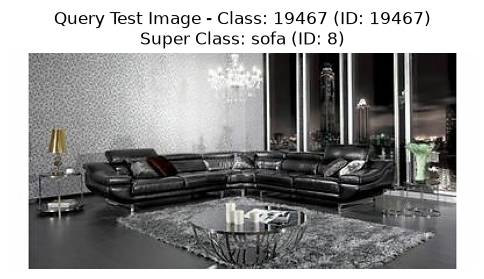

Stored query image embedding from index 0 with shape torch.Size([1, 256])


In [48]:
# Find a deterministic sample (e.g., the first one) from ds_test dataset
# To do so we need to re-iterate or use .take(sample_idx+1).skip(sample_idx)
# for a specific raw example. For simplicity, we get the first raw_image_np
# ensuring ds_test is available from cell W0OQHNC01Oas

# Define D_sop here as it is used later in this cell
n_embeddings = image_embeddings.shape[1]

if "ds_test" in locals():
    # Take the first example from the test dataset
    # We'll use this as our query image
    query_image_index = 0  # Define the index of the image to use for query
    first_example = next(iter(ds_test.skip(query_image_index).take(1).as_numpy_iterator()))
    raw_image_np = first_example["image"]
    original_class_id = first_example["class_id"]
    original_super_class_id = first_example["super_class_id"]

    # Convert numpy array to PIL Image for displaying
    display_image_pil = Image.fromarray(raw_image_np)

    # Get human-readable labels from TFDS metadata
    # Ensuring 'info' object (from NJh6zo5I_Sa9) is available or re-fetch it
    info = tfds.builder("stanford_online_products").info

    class_label_text = f"Class ID: {original_class_id}"
    # Attempt to get human-readable name for class_id if available
    if (
        "class_id" in info.features
        and hasattr(info.features["class_id"], "names")
        and info.features["class_id"].names
    ):
        class_label_text = (
            f"Class: {info.features['class_id'].names[original_class_id]} (ID: {original_class_id})"
        )

    super_class_label_text = f"Super Class ID: {original_super_class_id}"
    # Attempt to get human-readable name for super_class_id if available
    if (
        "super_class_id" in info.features
        and hasattr(info.features["super_class_id"], "names")
        and info.features["super_class_id"].names
    ):
        super_class_label_text = f"Super Class: {info.features['super_class_id'].names[original_super_class_id]} (ID: {original_super_class_id})"

    plt.figure(figsize=(6, 6))
    plt.imshow(display_image_pil)
    plt.title(f"Query Test Image - {class_label_text}\n{super_class_label_text}")
    plt.axis("off")
    plt.show()

    # Store the embedding of this query image for future use
    query_image_embedding = image_embeddings[query_image_index, :].reshape(1, n_embeddings)
    print(
        f"Stored query image embedding from index {query_image_index} with shape {query_image_embedding.shape}"
    )
else:
    print(
        "TFDS test dataset 'ds_test' not found. Please ensure the cell loading the dataset was executed."
    )

With the query image selected, the image must be embedded. Execute this code to compute the embedding.    

In [49]:
# Re-compute the query image embedding from the test dataset
# EDITED by Claude, following the fix described on the course Ed Discussion thread: build query_test_dataset from
# ds_test.skip(query_image_index).take(1) instead of the full ds_test, and
# index the result at [0] instead of [query_image_index]. The original line
# ran TFDSImageDataset's full materialization over all 60,502 test images
# just to read the single one at query_image_index, which pegged the CPU.
# Same fix proposed on the course Ed Discussion thread I copied in (Tim
# Bohlemann), which Prof. Stephen Elston confirmed gives the correct query
# image.
query_test_dataset = TFDSImageDataset(ds_test.skip(query_image_index).take(1), preprocess)

# Get the specific preprocessed image for the query from the test dataset
# query_image_index is already defined as 0; ds_test above was already
# skipped to that index, so the one sample in query_test_dataset is it.
query_image_tensor, _ = query_test_dataset[0]

model.eval()
with torch.no_grad():
    # Add a batch dimension and move to device
    query_image_input = query_image_tensor.unsqueeze(0).to(device)
    # Encode the image
    query_image_feat = model.encode_image(query_image_input)
    # Apply the dimension reduction projection layer
    query_image_feat = projection_layer(query_image_feat)
    # Normalize the embedding
    query_image_embedding = query_image_feat / query_image_feat.norm(dim=-1, keepdim=True)

print(
    f"Correctly re-computed query image embedding from ds_test (index {query_image_index}, original class_id 19467) with shape {query_image_embedding.shape}"
)

Correctly re-computed query image embedding from ds_test (index 0, original class_id 19467) with shape torch.Size([1, 256])


### Construct the index and perform the search    

With the embeddings computed we can now construct the index. To improve the results while limiting the memory a composite index is used. Execute this code to construct the index.     

In [50]:
D_sop = image_embeddings.shape[1]  # Dimension of SOP image embeddings, now 256

# Create the composite index without PCA, as embeddings are already reduced
index_IVFHNSWPQ_images = faiss.index_factory(D_sop, "OPQ32,IVF4096_HNSW,PQ32")

# Train the index with SOP image embeddings
index_IVFHNSWPQ_images.train(image_embeddings.numpy())
# Add the vectors into the indexer
index_IVFHNSWPQ_images.add(image_embeddings.numpy())

print(f"Index size: {get_memory(index_IVFHNSWPQ_images)} MB")

Index size: 8.25 MB


> **Exercise 5-7:**
> 1. The index size is displayed above. Compute the size of the original image database of size about $6 \times 10^4$ and the embedded image set of the same size using the following parameters:    
>     i. Assume the images can be down-sampled to $128 \times 128$ 8 bit (unsigned int) pixels for each of the 3 RGB channels, a compression factor of about 40-60. Compute the size of the down-sampled images database as it would be used with a naive search algorithm.    
>    ii. The embedding space is comprised of vectors of 256, 4 byte floating point numbers. Compute the size of the embedding space.    
> 2. What does the relative sizes of these databases and data structures tell you about the scalability of the using the compound index for ANNS as opposed to naive exact searches? Keep in mind that additional data can be added to an index using the current training.         

> **Answers:**
> 1. Computations for the two data structures.
>     - **i.** The down-sampled image database: 128x128x3 x 8 X ~6x10^4 = 23592960000 bits
>     - **ii.** Embedding space: 256 x 4 x ~6x10^4 = 61440000 bytes x 8 = 491520000 bits
> 2. The ratio between the two is 23592960000/491520000 = 48. One thing to note is that the size of the database (the x ~6x10^4) would cancel out from both formulas if we represented them as a ratio, so this ratio is actually static regardless of database size. This tells us they both scale linearly with the size of the database, but the compound index increases at 1/48 the rate. Also the compound index's marginal cost of growth stays cheap (train once, add easily) while keeping query time better than linear, but the naive approach while it does have a minimal marginal cost of growth, search time gets worse linearly as the size increases. 

With the index computed, the query can be performed to find the top 100 nearest neighbors in the embedding space. Execute the code in the cell below and examine the results.         

In [51]:
k=100
%time dist, I_sop = index_IVFHNSWPQ_images.search(query_image_embedding.cpu().numpy(), k)

NNs_SOP_image = pd.DataFrame({'Neighbor':I_sop[0], 'Distance':dist[0]})
print(NNs_SOP_image.head())

CPU times: total: 0 ns
Wall time: 870 μs
   Neighbor  Distance
0     29521  0.243167
1      1383  0.259036
2     58148  0.263010
3     59432  0.281586
4     39325  0.285475


### Evaluate the results     

There are a number of ways we can evaluate the search results. In this case the dataset is small can use a simple process using the results of an exact search.   
1. Compute an exact index.    
2. Query the exact index.    
3. Compute recall at the specified levels of k.

To perform the first comparison execute the code in the cell below.   

In [52]:
# 1. Create a Flat (L2) Index for SOP image embeddings to establish ground truth
l2_index_sop = faiss.IndexFlatL2(D_sop)
l2_index_sop.add(image_embeddings.numpy())

# 2. Perform an exact search for the query image (from test set) to get ground truth NNs
k = 100  # Using the same k as the approximate search
dist_gt, I_sop_gt = l2_index_sop.search(query_image_embedding.cpu().numpy(), k)

NNs_SOP_image_ground_truth = pd.DataFrame({"Neighbor": I_sop_gt[0], "Distance": dist_gt[0]})

print("Ground Truth Nearest Neighbors (first 5):")
print(NNs_SOP_image_ground_truth.head())

Ground Truth Nearest Neighbors (first 5):
   Neighbor  Distance
0     47751  0.243433
1     54100  0.249571
2     16461  0.253214
3     58148  0.256124
4      5351  0.258675


The code in the cell below uses the super class of the image labels to compute the recall of the ANNS vs. the exact search. Execute this code and examine the results.      

In [53]:
# Get super class IDs for the approximate nearest neighbors
# (excluding the query itself removed as query is not in index)
approx_neighbor_indices = NNs_SOP_image.Neighbor.tolist()
# Filter out -1 values which indicate no neighbor found in approximate search
approx_neighbor_indices = [idx for idx in approx_neighbor_indices if idx != -1]
approx_neighbor_super_class_ids = [
    dataset.samples[idx]["super_class_id"].item() for idx in approx_neighbor_indices
]

# Get super class IDs for the ground truth nearest neighbors
# (excluding the query itself removed as query is not in index)
gt_neighbor_indices = NNs_SOP_image_ground_truth.Neighbor.tolist()
gt_neighbor_super_class_ids = [
    dataset.samples[idx]["super_class_id"].item() for idx in gt_neighbor_indices
]

# Print the super class ID of the query image for context
print(f"Query Image's Super Class ID: {original_super_class_id}")

# Compute recall using super class IDs
recall_results_super_category = compute_recall(
    approx_neighbor_super_class_ids, gt_neighbor_super_class_ids
)

print(
    "Recall for Image Similarity Search (by super category labels, comparing approx vs. ground truth neighbors):"
)
display(recall_results_super_category)

Query Image's Super Class ID: 8
Recall for Image Similarity Search (by super category labels, comparing approx vs. ground truth neighbors):


,at k,Recall
0,1,1.00
1,2,1.00
2,10,1.00
3,20,1.00
4,100,0.31


### Improving the search results   

The results so far are not ideal. The question is, how can we improve the performance of the model? An obvious choice step is to increase the `nprobes` hyperparameter from the default of 1. The code in the cell below updates the `nprobs` hyperparameter for the index to 128. Execute this code and examine the results.     

In [54]:
imi_sop = faiss.extract_index_ivf(index_IVFHNSWPQ_images)  # Extract the IVF part
imi_sop.nprobe = 128  # Set nprobe to a higher value

k = 100  # Ensure k is defined for this context
# Re-run the approximate search after setting nprobe
dist, I_sop = index_IVFHNSWPQ_images.search(query_image_embedding.cpu().numpy(), k)
NNs_SOP_image = pd.DataFrame({"Neighbor": I_sop[0], "Distance": dist[0]})

approx_neighbor_indices_exact = NNs_SOP_image.Neighbor.tolist()
gt_neighbor_indices_exact = NNs_SOP_image_ground_truth.Neighbor.tolist()

# Filter out -1 values which indicate no neighbor found in approximate search
approx_neighbor_indices_exact = [idx for idx in approx_neighbor_indices_exact if idx != -1]

# Compute recall using exact neighbor indices
recall_results_exact = compute_recall(approx_neighbor_indices_exact, gt_neighbor_indices_exact)

print("Recall for Image Similarity Search (by exact neighbor indices, excluding query itself):")
display(recall_results_exact)

Recall for Image Similarity Search (by exact neighbor indices, excluding query itself):


,at k,Recall
0,1,0.00
1,2,0.00
2,10,0.80
3,20,0.75
4,100,0.76


> **Exercise 5-8:**
> 1. Explain how is it possible to update the `nprobs` hyperparameter for the ANNS index without re-training.
> 2. What is the relative impact on performance at query time of increasing the number of probes?
> 3. Compare the performance of model with the two values of the `nprobs`. Explain why the model with the larger value of `nprobs` has better performance.    

> **Answers:**
> 1. nprob is related to querying not to training, it is the number of probes used in a query so you can change it between queries without retraining.    
> 2. At nprobe=1 wall time =.203s, at nprobe=8 wall time = 1.31s (about a 6.45x increase for 8x  increase in probes), and at nprobe=16 wall time = 2.43 (a 1.85x increase for 2x increase in probes). It looks like there is a baseline time requirement that gets 'diluted' as a higher percentage of the time is taken up from the nprobes increase, which scale sub-linearly.     
> 3. At nprobe=1 recall drops quite a bit by k=100, whereas at nprobe=128 it only drops a small amount from .8 at k=1 and seems to stop around .75 since it goes back to .76 after that. When nprobe=1 we only check one cell for nearest neighbors, and could fail to find the correct answer. When nprobe increases we probe more cells and decrease this chance.                   

### Examining the results      

Finally, let's have a visual check on the results. The query image shows a rather large and expensive-looking sofa. Execute the code in the cell below to display the top 5 images found by the ANNS.  

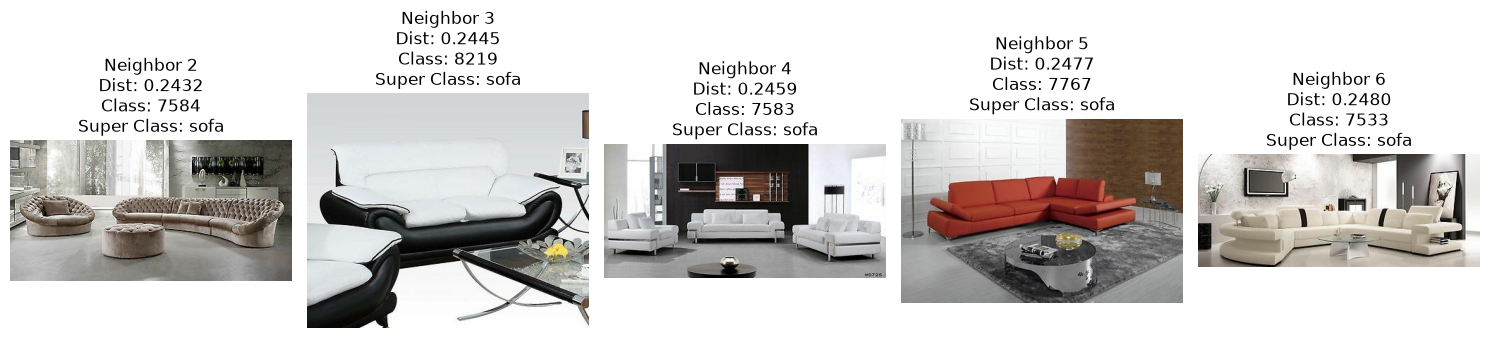

In [55]:
num_neighbors_to_display = 5

plt.figure(figsize=(15, 5))
for i in range(num_neighbors_to_display):
    # Adjust index to start from the 2nd nearest neighbor (index 1) and take 5 subsequent ones
    neighbor_index = NNs_SOP_image["Neighbor"].iloc[i + 1]
    # Retrieve the original image from the dataset using its index
    # The dataset stores the original numpy array before preprocessing
    image_np = dataset.samples[neighbor_index]["image"]

    # Get class and super class IDs from the dataset sample
    class_id = dataset.samples[neighbor_index]["class_id"]

    # Convert numpy array to PIL Image for displaying
    display_image_pil = Image.fromarray(image_np)

    # Get human-readable labels from TFDS metadata
    # Ensuring 'info' object is available (from previous cells)

    class_name = (
        info.features["class_id"].names[class_id]
        if "class_id" in info.features
        and hasattr(info.features["class_id"], "names")
        and info.features["class_id"].names
        else f"Class ID: {class_id}"
    )

    super_class_name = "N/A"  # Default value
    if "super_class_id" in dataset.samples[neighbor_index]:
        super_class_id = dataset.samples[neighbor_index]["super_class_id"]
        super_class_name = (
            info.features["super_class_id"].names[super_class_id]
            if "super_class_id" in info.features
            and hasattr(info.features["super_class_id"], "names")
            and info.features["super_class_id"].names
            else f"Super Class ID: {super_class_id}"
        )

    plt.subplot(1, num_neighbors_to_display, i + 1)
    plt.imshow(display_image_pil)
    plt.title(
        f"Neighbor {i+2}\nDist: {NNs_SOP_image['Distance'].iloc[i + 1]:.4f}\nClass: {class_name}\nSuper Class: {super_class_name}"
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

These results look quite reasonable! The images show a variety of couches.  

#### Copyright 2024, 2025, 2026, Stephen F Elston. All rights reserved.